

`Práctica Nº1 - Aprendizaje Profundo`



#**CLASIFICACIÓN DE IMAGENES CON CNN**

##*DataSet: APTOS 2019 – Detección de Retinopatía Diabética (Ceguera)*

### 00. DataSet

Se utiliza el conjunto de imágenes APTOS 2019, que contiene fotografías de retina etiquetadas según el nivel de severidad de la retinopatía diabética, organizadas en cinco clases.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!apt-get install -y unrar

from pathlib import Path
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.


In [ ]:
rar_path = Path('/content/drive/MyDrive/Dataset - AP/blindness.rar')

In [ ]:
output_path = Path('/content/data_blindness')

In [ ]:
if not (output_path/'blindness').exists():
    !mkdir -p /content/data_blindness
    !unrar x "/content/drive/MyDrive/Dataset - AP/blindness.rar" /content/data_blindness/
else:
    print("Dataset ya disponible")

Dataset ya disponible


### 01. Librerias

In [ ]:
from fastai.vision.all import *

path = Path('/content/data_blindness/blindness')

trainPath = path/'train'
testPath = path/'test'

print("Train:", trainPath.exists())
print("Test:", testPath.exists())

print("Clases en train:", [p.name for p in trainPath.ls() if p.is_dir()])

Train: True
Test: True
Clases en train: ['2', '0', '1', '4', '3']


### 02. Conteo de imágenes

In [ ]:
n_train = len(get_image_files(trainPath))
n_test = len(get_image_files(testPath))

print("Imágenes de entrenamiento:", n_train)
print("Imágenes de test:", n_test)

Imágenes de entrenamiento: 2749
Imágenes de test: 913


### 03. DataBlock

In [ ]:
db = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.15, seed=42),
    get_y=parent_label,
    item_tfms=Resize(512),
    batch_tfms=[
        *aug_transforms(
            size=256,
            max_rotate=15,
            flip_vert=True,
            min_scale=1.0
        ),
        Normalize.from_stats(*imagenet_stats)
    ]
)

### 04. DataLoaders

Clases detectadas: ['0', '1', '2', '3', '4']


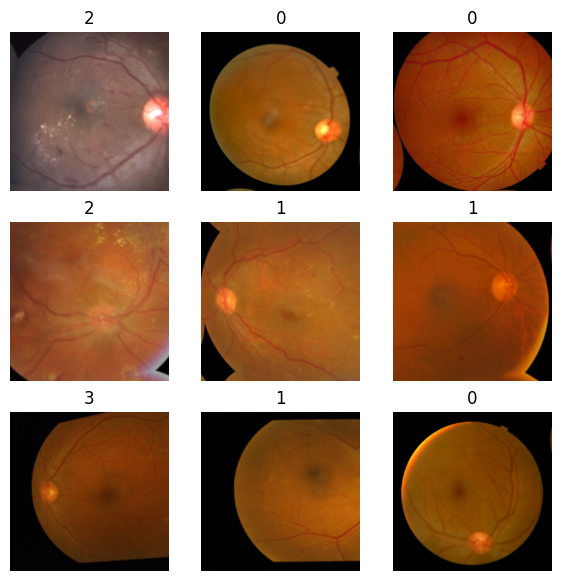

In [ ]:
dls = db.dataloaders(trainPath, bs=32)

print("Clases detectadas:", dls.vocab)

dls.show_batch(max_n=9, figsize=(7,7))

La visualización de un batch permite verificar que las imágenes y sus etiquetas se han cargado correctamente, así como comprobar que las transformaciones de aumento de datos se están aplicando de forma adecuada.

### 05. Entrenando el modelo



> Callbacks



In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='valid_loss', patience=5),
    SaveModelCallback(monitor='valid_loss', fname='resnet34_aptos2019')
]



> Modelo



In [ ]:
learn = vision_learner(
    dls,
    resnet34,
    metrics=[accuracy, Precision(average='macro'), Recall(average='macro')],
    cbs=callbacks
).to_fp16()

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 209MB/s]




> Learning Rate


<div></div>

Learning rate: 0.0010000000474974513


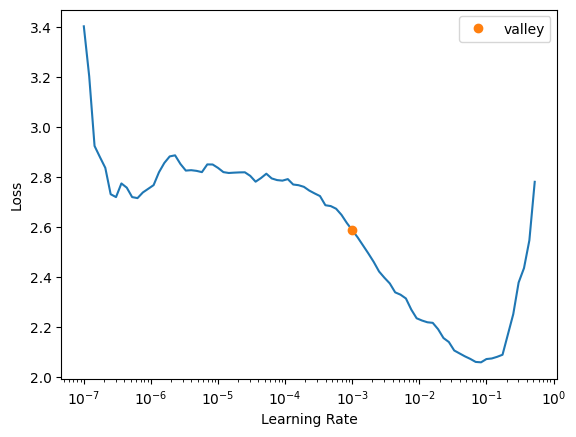

In [ ]:
lr_sug = learn.lr_find()

lr = lr_sug.valley
print("Learning rate:", lr)



> Fine-tuning (entrenamiento)



epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,time
0,1.663572,0.999716,0.679612,0.477385,0.451824,00:24


Better model found at epoch 0 with valid_loss value: 0.9997158050537109.


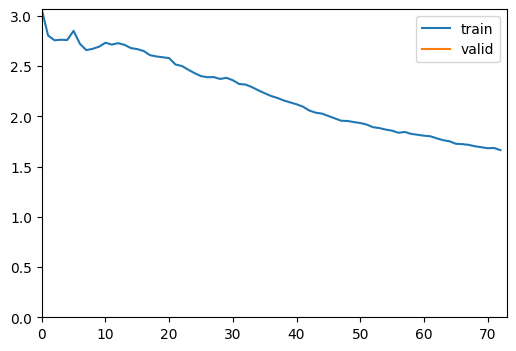

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,time
0,1.074759,0.865239,0.682039,0.487967,0.472342,00:24
1,0.930696,0.819141,0.691748,0.487810,0.481659,00:24
2,0.831343,0.790448,0.733010,0.556420,0.530402,00:25
3,0.759418,0.690707,0.754854,0.670242,0.532796,00:24
4,0.668538,0.672101,0.754854,0.606626,0.561678,00:24
5,0.623463,0.672938,0.764563,0.634547,0.556122,00:25
6,0.567875,0.641732,0.766990,0.616202,0.587222,00:23
7,0.525395,0.631332,0.771845,0.657571,0.582064,00:25
8,0.499394,0.634911,0.783981,0.677207,0.592535,00:25
9,0.500968,0.643641,0.781553,0.663468,0.595406,00:23


Better model found at epoch 0 with valid_loss value: 0.8652389645576477.


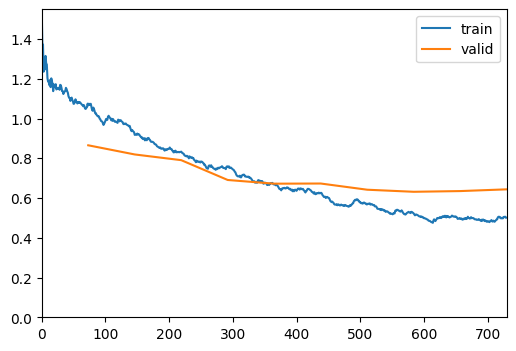

Better model found at epoch 1 with valid_loss value: 0.8191412687301636.
Better model found at epoch 2 with valid_loss value: 0.7904477715492249.
Better model found at epoch 3 with valid_loss value: 0.6907071471214294.
Better model found at epoch 4 with valid_loss value: 0.6721007227897644.
Better model found at epoch 6 with valid_loss value: 0.6417319774627686.
Better model found at epoch 7 with valid_loss value: 0.6313323378562927.


In [ ]:
learn.fine_tune(10, base_lr=lr)



> Modelo guardado


In [ ]:
learn.to_fp32()
learn.export('export_aptos.pkl')

### 06. Evaluando en Test

In [ ]:
dbTest = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=GrandparentSplitter(valid_name='test'),
    get_y=parent_label,
    item_tfms=Resize(512),
    batch_tfms=[Normalize.from_stats(*imagenet_stats)]
)

dlsTest = dbTest.dataloaders(path, bs=32)

learn.dls = dlsTest

test_results = learn.validate()
print("Resultados en test:", test_results)

Better model found at epoch 0 with valid_loss value: 0.6998904943466187.
Resultados en test: [0.889832079410553, 0.6998904943466187, 0.7474366585898097, 0.5009215046706359]


### 07. Interpretación del modelo



> Matriz de Confusión



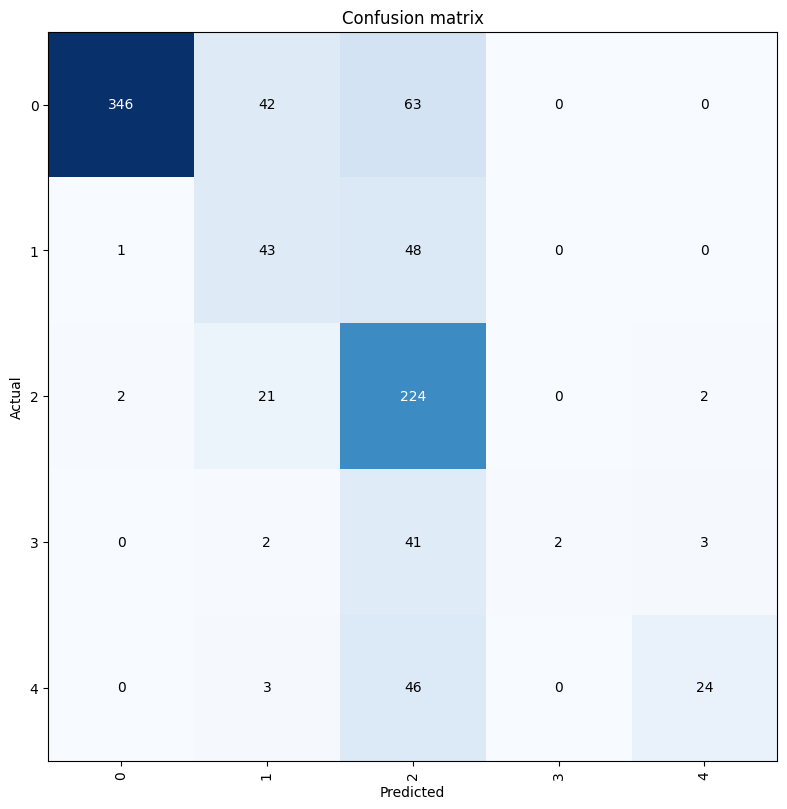

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)

interp.plot_confusion_matrix(figsize=(8,8))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


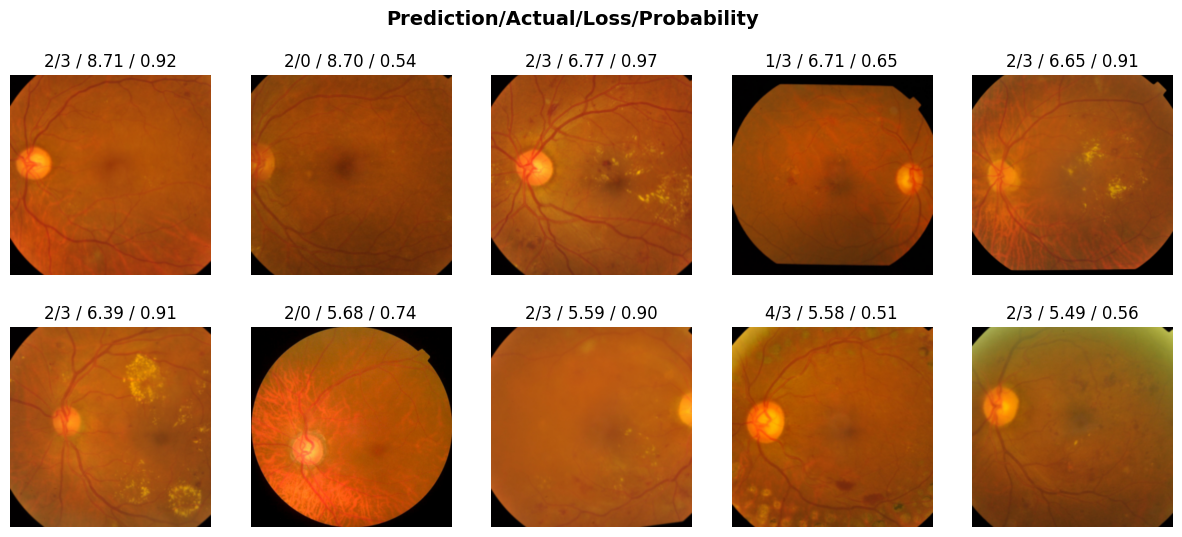

In [ ]:
interp.plot_top_losses(10, nrows=2)

### 08. Usando y creando aplicacion del modelo

In [ ]:
learn_inf = load_learner('export_aptos.pkl')

imgs = get_image_files(testPath)
img_path = imgs[0]

print("Imagen usada:", img_path)

pred_class, pred_idx, probs = learn_inf.predict(img_path)

print("Clase predicha:", pred_class)
print("Índice:", pred_idx)
print("Probabilidades:", probs)

Imagen usada: /content/data_blindness/blindness/test/2/a125377fb985.png


/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


Clase predicha: 2
Índice: tensor(2)
Probabilidades: tensor([1.0802e-05, 7.1036e-03, 9.6954e-01, 1.4680e-02, 8.6696e-03])


### 09. Subir a Hugging Face

In [ ]:
!pip install -U "huggingface_hub[fastai]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 19.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1


In [ ]:
from fastai.vision.all import *
from huggingface_hub import notebook_login, push_to_hub_fastai

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
learn = load_learner('export_aptos.pkl')

push_to_hub_fastai(learner=learn, repo_id="Clau31/aptos-practica1")

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...aptos-practica1/model.pkl:   1%|          |  565kB / 87.5MB            

CommitInfo(commit_url='https://huggingface.co/Clau31/aptos-practica1/commit/ceef746635da0e423568f0292537cf81ec9b6f27', commit_message='Push FastAI model using huggingface_hub.', commit_description='', oid='ceef746635da0e423568f0292537cf81ec9b6f27', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Clau31/aptos-practica1', endpoint='https://huggingface.co', repo_type='model', repo_id='Clau31/aptos-practica1'), pr_revision=None, pr_num=None)

# **EJERCICIOS EXTRAS**



> Label Smoothing



In [ ]:
dls_ls = db.dataloaders(trainPath, bs=32)

In [ ]:
callbacks_ls = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='valid_loss', patience=5),
    SaveModelCallback(monitor='valid_loss', fname='resnet34_aptos_labelsmoothing')
]

In [ ]:
#Modelo con Label Smoothing
learn_ls = vision_learner(
    dls_ls,
    resnet34,
    loss_func=LabelSmoothingCrossEntropy(),
    metrics=[accuracy, Precision(average='macro'), Recall(average='macro')],
    cbs=callbacks_ls
).to_fp16()

<div></div>

Learning rate: 0.0004786300996784121


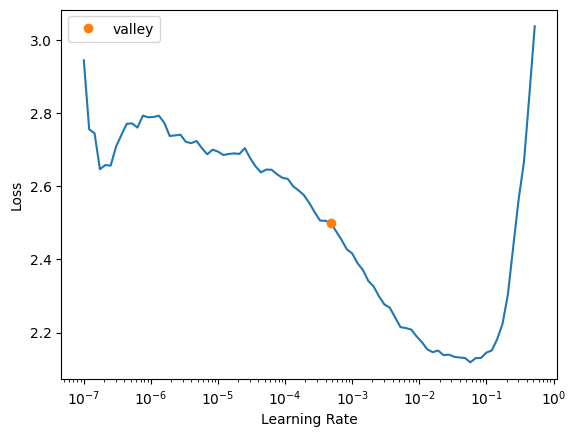

In [ ]:
lr_sug_ls = learn_ls.lr_find()
lr_ls = lr_sug_ls.valley
print("Learning rate:", lr_ls)

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,time
0,1.866980,1.242146,0.684466,0.476219,0.436292,00:24


Better model found at epoch 0 with valid_loss value: 1.2421455383300781.


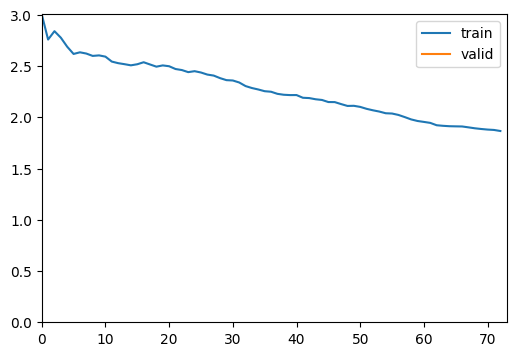

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,time
0,1.481962,1.175925,0.699029,0.505485,0.453387,00:24
1,1.366348,1.121043,0.723301,0.576498,0.479158,00:23
2,1.282048,1.081800,0.754854,0.621985,0.542808,00:24
3,1.240226,1.106716,0.740291,0.630438,0.495323,00:22
4,1.174157,1.033627,0.747573,0.635220,0.541420,00:24
5,1.116227,0.993238,0.750000,0.625957,0.559246,00:24
6,1.064438,1.002517,0.764563,0.657983,0.573445,00:22
7,1.051211,1.005213,0.747573,0.624306,0.542582,00:24
8,1.007038,1.002050,0.747573,0.618908,0.537770,00:22
9,0.995998,0.991203,0.754854,0.633570,0.553220,00:24


Better model found at epoch 0 with valid_loss value: 1.1759251356124878.


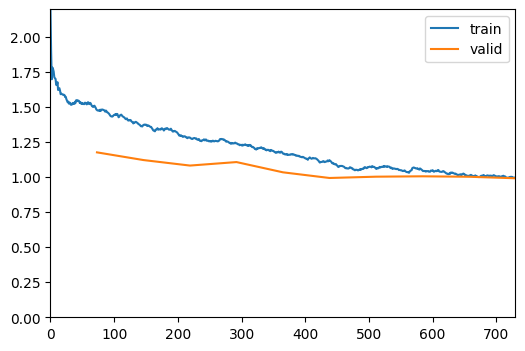

Better model found at epoch 1 with valid_loss value: 1.121043086051941.
Better model found at epoch 2 with valid_loss value: 1.081800103187561.
Better model found at epoch 4 with valid_loss value: 1.0336272716522217.
Better model found at epoch 5 with valid_loss value: 0.9932383298873901.
Better model found at epoch 9 with valid_loss value: 0.9912027716636658.


In [ ]:
learn_ls.fine_tune(10, base_lr=lr_ls)

In [ ]:
resultados_ls = evaluar_en_test(learn_ls)

In [ ]:
#Guardar modelo exportado
learn_ls.to_fp32()
learn_ls.export('export_aptos_labelsmoothing.pkl')